# Project: Neutrino Portal at the Muon Collider

## Load Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import pathlib
import matplotlib.pyplot as plt
import matplotlib
import json

## Load all events 

Explanation for file format of MC_-14_3TeV_with_cut_with_final.txt: 
- The first column in the file is energy in GeV. 
- The second column is the flux of $\nu_{\mu}$ per year. 
- The third column is the flux of $\bar\nu_{e}$ per year. 
- The remaining columns are for cross sections of the different charged and neutral current processes for $\nu_{\mu}$ and $\bar\nu_{e}$ in units of $cm^{2}$. 

The cross sections have been obtained using pythia.SigmaGen() and compared with cross-section produced by GENIE. The last two columns correspond to cross section at $\lambda_{\mu\mu}$=1 for the two signals at mass 125MeV and 20 GeV. The cross section has been obtained using MADGRAPH. For the two signals, the flux of incoming neutrinos is considered to be that of $\nu_{\mu}$ as it is the source from which signals originate.

To get the event weight, we divide the number of interacting neutrinos per year by the number of monte carlo events generated to normalize it. 
\begin{equation}
N_{\nu} =\frac{\sigma\times\rho\times l_{det}\times10^{-36}\times N_{inc}}{m_{p}} 
\end{equation}

Here, $\sigma\times10^{-36}$ is the cross section in $cm^{2}$, $\rho$ is the density of iron in $g/cm^{3}$, $l_{det}$ is the length of detector in centimeters, $N_{inc}$ is the number of incident neutrinos per year and $m_p$ is the mass of proton in gram. 

In [2]:
def load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final.txt'):
    
    #initialize numbers
    rho = 7.874            # density of iron in g/cm3
    mass = 1.67e-24        # mass of proton in g 
    l_det = 4.0425         # length of detector for iron for 10 kg in cm
    mul = rho*l_det/mass   # area density, in 1/cm2
    #nevent = 1e7           # No. of MC events 

    #initialize output 
    all_data = None
    
    #import data on fluxes and cross sections
    scaling_data = pd.read_csv(scaling_file, delim_whitespace=True) 
    scaling_data['energy'] = round(scaling_data['energy'],0)
    
    #loop over datasets 
    datasets = ['NC_nuebar', 'CC_nuebar', 'CC_numu', 'NC_numu',"0.125GeV","20GeV"]
    for dataset in datasets:
        
        # get all files and loop over them
        dirname = 'output_events_' + dataset  
        directory = pathlib.Path(dirname)
        files = sorted(directory.rglob('observables_*.csv.zip'))
        
        #import data on generated event rates
        generated_data_name = dirname+"/generated_events.json"
        with open(generated_data_name, "r") as f: generated_data_raw = json.load(f)
        generated_data = {int(float(key)): value for key, value in generated_data_raw.items()}

        for file in files:
            #logging
            #print("load file: "+ str(file))
            
            # get beam energy
            energy = float(str(file).split('_')[-1].replace('.csv.zip', ''))
                
            # load data, get observables
            observables = pd.read_csv(str(file))
            observables['set'] = dataset
            #if dataset in ['NC_nuebar', 'CC_nuebar', 'CC_numu', 'NC_numu']: observables['label'] = 0
            #else: observables['label'] = 1
            print("load file: "+ str(file), len(observables))
            
            ### obtain number of events (allows for different nevents for different energies)
            nevent = generated_data[int(energy)]
            
            # calculate scaling factor            
            scaling_row = scaling_data[scaling_data['energy'] == round(energy,0)]
            cross_section = scaling_row[dataset].values[0]
            if dataset in ['NC_nuebar', 'CC_nuebar', 'CC_numu', 'NC_numu']:
                flux = scaling_row[dataset[3:]+"_flux"].values[0]
            else:
                flux = scaling_row["numu_flux"].values[0]
            weight = ((cross_section * flux * mul)/nevent)    
            observables['weight'] = weight
            
            # combine data
            if all_data is None: all_data = observables
            else:all_data = pd.concat([all_data, observables])
    
    return all_data.reset_index(drop=True)


In [3]:
data0 = load_everything(scaling_file='MC_-14_3TeV_with_cut_with_final_output.txt')

load file: output_events_NC_nuebar/observables_112.94.csv.zip 15598
load file: output_events_NC_nuebar/observables_1129.46.csv.zip 119176
load file: output_events_NC_nuebar/observables_14.21.csv.zip 1162
load file: output_events_NC_nuebar/observables_142.19.csv.zip 18674
load file: output_events_NC_nuebar/observables_1421.9.csv.zip 130966
load file: output_events_NC_nuebar/observables_17.9.csv.zip 1838
load file: output_events_NC_nuebar/observables_179.0.csv.zip 21699
load file: output_events_NC_nuebar/observables_22.53.csv.zip 2717
load file: output_events_NC_nuebar/observables_225.35.csv.zip 25585
load file: output_events_NC_nuebar/observables_28.37.csv.zip 3673
load file: output_events_NC_nuebar/observables_283.7.csv.zip 29544
load file: output_events_NC_nuebar/observables_35.71.csv.zip 4919
load file: output_events_NC_nuebar/observables_357.16.csv.zip 33655
load file: output_events_NC_nuebar/observables_44.964.csv.zip 6642
load file: output_events_NC_nuebar/observables_449.64.csv.z

## Functions

In [72]:
def get_rates(data, header=None, factor=1):
    
    # print header
    if header is not None: print(header+":")
    
    # get event rates and MC staistics for all processes
    for dataset in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar',"0.125GeV","20GeV"]:
        n_mc = len(data[data['set']==dataset])
        n_real = sum(data[data['set']==dataset]['weight'])*factor
        print ("   "+dataset+": " + str(n_real)+ " (N_MC = "+str(n_mc)+")")
               
def get_stacked_histogram(data, observable, bins, xlabel, xlog=False, coupling=1, factor=1):
               
    # setup figure
    datasets = {'NC_numu':"red", 'NC_nuebar':"firebrick", 'CC_numu':"dodgerblue", 'CC_nuebar':"blue"}
    labels = {'CC_numu':r"CC $\nu_\mu$", 'CC_nuebar':r"CC $\nu_e$", 'NC_numu':r"NC $\nu_\mu$", 'NC_nuebar':r"NC $\nu_e$"}
    matplotlib.rcParams.update({'font.size': 14})
    matplotlib.rcParams['text.usetex'] = False
    fig = plt.figure(figsize=(12,4.5))
    
    #plot background 
    ax1 = plt.subplot(1,2,1)   
    ax2 = plt.subplot(1,2,2)   
    used_sets = []
    for idata, dataset in enumerate(datasets.keys()):
        
        #get stuff
        used_sets.append(dataset)
        subset = data[data['set'].isin(used_sets)].copy()
        x, w = subset[observable], subset['weight'] * factor
        c, l = datasets[dataset], labels[dataset]
        
        # linear y-axis   
        ax1.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
        
        # log y axis
        ax2.hist(x, weights=w, histtype='bar', stacked=True, bins=bins, color=c, label = l,zorder=-idata)
    
    #plot signal 
    signals = {'0.125GeV':["$m_{\phi}$=125MeV","dashed"]}
    for signal in signals.keys():
        
        #get stuff
        subset_bkg = data[data['set'].isin(datasets.keys())].copy()
        subset_sig = data[data['set']==signal].copy()
        subset_sig['weight'] =  subset_sig['weight'] * coupling**2
        subset = pd.concat([subset_sig,subset_bkg])
        l,ls = signals[signal]
            
        # plot sig+bkg
        x, w = subset[observable], subset['weight']  * factor
        ax1.hist(x, weights=w, histtype='step', bins=bins, color='k', label = l, ls=ls)
        ax2.hist(x, weights=w, histtype='step', bins=bins, color='k', label = l, ls=ls)
        
        # plot sig+bkg
        x, w = subset_sig[observable], subset_sig['weight']  * factor
        ax1.hist(x, weights=w, histtype='step', bins=bins, color='gray',  ls=ls)
        ax2.hist(x, weights=w, histtype='step', bins=bins, color='gray',  ls=ls)

    # linear y-axis           
    if xlog: ax1.set_xscale("log")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(r"Interacting Neutrinos")
    ax1.legend(frameon=False, labelspacing=0, fontsize=12)
          
    # log y axis     
    if xlog: ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel(xlabel)
    ax2.set_ylim(ax2.get_ylim()[1]/1e3, ax2.get_ylim()[1])
    ax2.set_ylabel(r"Interacting Neutrinos")
    ax2.legend(frameon=False, labelspacing=0, fontsize=12)
         
    #finalize
    plt.tight_layout()
    plt.show()
    
def plot_2d(
        data0, 
        data1, 
        varx='e_mu_plus', 
        vary='e_visible', 
        binsx = [1,4,30],
        binsy = [1,4,30],
        label0 = 'Background',
        label1 = 'Signal'
    ):
    
    # remove 0s 
    data0 = data0[(data0[varx]>0) & (data0[vary]>0) ].copy()
    data1 = data1[(data1[varx]>0) & (data1[vary]>0) ].copy()
    
    #ticks and edges
    ticks = np.array([[np.linspace(10**(j),10**(j+1),9)] for j in range(-7,6)]).flatten()
    ticks = [np.log10(x) for x in ticks]
    ticklabels = np.array([[r"$10^{"+str(j)+"}$","","","","","","","",""] for j in range(-7,6)]).flatten() 
    tmin, tmax, tnum = binsx[0], binsx[1], binsx[2]+1
    pmin, pmax, pnum = binsy[0], binsy[1], binsy[2]+1
    t_edges = np.linspace(tmin, tmax, num=tnum+1)
    p_edges = np.linspace(pmin, pmax, num=pnum+1)
    t_centers = np.logspace(tmin+0.5*(tmax-tmin)/float(tnum), tmax-0.5*(tmax-tmin)/float(tnum), num=tnum)
    p_centers = np.logspace(pmin+0.5*(pmax-pmin)/float(pnum), pmax-0.5*(pmax-pmin)/float(pnum), num=pnum) 
    
    #initialize figure
    matplotlib.rcParams.update({'font.size': 15})
    fig = plt.figure(figsize=(18,5))
    
    ax = plt.subplot(1,3,1)
    h0=ax.hist2d(x=np.log10(data0[varx]),y=np.log10(data0[vary]),weights=data0['weight'],
            bins=[tnum,pnum],range=[[tmin,tmax],[pmin,pmax]],
            norm=matplotlib.colors.LogNorm(vmin=None, vmax=None), cmap="rainbow",
    )
    #ax.scatter(x=np.log10(data0[varx]),y=np.log10(data0[vary]),c='k')
    fig.colorbar(h0[3], ax=ax)
    ax.set_title(label0)
    ax.set_xlabel(varx)
    ax.set_ylabel(vary)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels)
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(pmin, pmax)
    
    ax = plt.subplot(1,3,2)
    h1=ax.hist2d(x=np.log10(data1[varx]),y=np.log10(data1[vary]),weights=data1['weight'],
            bins=[tnum,pnum],range=[[tmin,tmax],[pmin,pmax]],
            norm=matplotlib.colors.LogNorm(vmin=None, vmax=None), cmap="rainbow",
    )
    #ax.scatter(x=np.log10(data1[varx]),y=np.log10(data1[vary]),c='k')
    fig.colorbar(h1[3], ax=ax)
    ax.set_title(label1)
    ax.set_xlabel(varx)
    ax.set_ylabel(vary)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels)
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(pmin, pmax)

    list_t, list_p, list_r = [], [], []
    for it,t in enumerate(t_centers):
        for ip,p in enumerate(p_centers):
            list_t.append(np.log10 ( t_centers[it] ) )
            list_p.append(np.log10 ( p_centers[ip] ) )
            list_r.append(0 if h0[0][it][ip]==0 else h1[0][it][ip]/h0[0][it][ip])
                
                
    ax = plt.subplot(1,3,3)
    h=ax.hist2d(x=list_t,y=list_p,weights=list_r,
            bins=[tnum,pnum],range=[[tmin,tmax],[pmin,pmax]],
            norm=matplotlib.colors.LogNorm(vmin=0.01, vmax=100), cmap="seismic",
    )
    fig.colorbar(h[3], ax=ax)
    ax.set_title('ratio')
    ax.set_xlabel(varx)
    ax.set_ylabel(vary)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels)
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(pmin, pmax)
    
    plt.tight_layout()
    plt.show()

## 1. Detector Smearing and Baseline Cuts

- isolate background and signal of interest

In [5]:
data = data0[data0['set'].isin(['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar', '0.125GeV'])].copy()

- smear energies by 10 % 

In [6]:
data['e_mu_plus'] = data['e_mu_plus'] *np.random.normal(loc=1.0, scale=0.1, size=len(data))
data['e_mu_minus'] = data['e_mu_minus'] *np.random.normal(loc=1.0, scale=0.1, size=len(data))
data['e_visible'] = data['e_visible'] *np.random.normal(loc=1.0, scale=0.1, size=len(data))
data['pt_mis'] = -data['pt_mis']

- require mu+ energy to be larger than 30 GeV
- require mu- energy to be less than 30 GeV 

In [7]:
data = data[data['e_mu_plus']>30].copy()
data = data[data['e_mu_minus']<30].copy()
get_rates(data, header = r"Baseline")

Baseline:
   CC_numu: 5382.628170337544 (N_MC = 69459)
   CC_nuebar: 109.26364730288299 (N_MC = 2539)
   NC_numu: 4988.048210511575 (N_MC = 131296)
   NC_nuebar: 2223.8668194498796 (N_MC = 140213)
   0.125GeV: 5250.520959279901 (N_MC = 233361)
   20GeV: 0 (N_MC = 0)


- Let's also add a feature deciding whether an event was charm tagged or not 

In [8]:
veto_prob = 0.8
data['random'] = np.random.random(len(data))
data['charm_tag'] = ((data['has_charm'] * data['random']) > veto_prob).astype(int)

- let's look at the rates

In [45]:
get_rates(data, header = r"Before BDT", factor=1)

Before BDT:
   CC_numu: 5382.628170337544 (N_MC = 69459)
   CC_nuebar: 109.26364730288299 (N_MC = 2539)
   NC_numu: 4988.048210511575 (N_MC = 131296)
   NC_nuebar: 2223.8668194498796 (N_MC = 140213)
   0.125GeV: 5250.520959279901 (N_MC = 233361)
   20GeV: 0 (N_MC = 0)


## 2. ML based analysis

In [10]:
#load ML libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

In [11]:
# Features and target
features = ['e_mu_minus', 'e_mu_plus', 'e_em', 'charm_tag', 'e_visible', 'pt_mis', 'ht']
#features = ['e_mu_plus', 'e_visible', 'e_em', 'pt_mis', 'ht']
X = data[features]
yset = data['set']
weights = data['weight']

In [12]:
# Split the data into training and test sets
test_size=0.3
X_train, X_test, yset_train, yset_test, weights_train, weights_test = train_test_split(
    X, yset, weights, test_size=test_size, random_state=42
)
y_train = pd.Series([0 if y in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar'] else 1 for y in yset_train])
y_test  = pd.Series([0 if y in ['CC_numu', 'CC_nuebar', 'NC_numu', 'NC_nuebar'] else 1 for y in yset_test])

In [13]:
# Define preprocessing: log-transform and scaling
log_transformer = FunctionTransformer(np.log1p, validate=True)  # Log(1 + x)
preprocessor = ColumnTransformer([
    ('log', log_transformer, ['e_mu_plus', 'e_visible', 'e_em']),  
    ('scale', StandardScaler(), features)    
])

In [14]:
# Create a pipeline with preprocessing and the classifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('bdt', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

In [15]:
# Train the model
_=pipeline.fit(X_train, y_train, bdt__sample_weight=weights_train)
#_=pipeline.fit(X_train, y_train)

In [16]:
# Make predictions
y_pred = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

In [17]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred, sample_weight=weights_test)
roc_auc = roc_auc_score(y_test, y_pred_prob, sample_weight=weights_test)

print(f"Accuracy (weighted): {accuracy:.4f}")
print(f"ROC AUC (weighted): {roc_auc:.4f}")
print("\nClassification Report (weighted):")
print(classification_report(y_test, y_pred, sample_weight=weights_test))


Accuracy (weighted): 0.9406
ROC AUC (weighted): 0.9806

Classification Report (weighted):
              precision    recall  f1-score   support

           0       0.95      0.97      0.96 3820.9326692092322
           1       0.92      0.87      0.89 1575.806256078822

    accuracy                           0.94 5396.738925288054
   macro avg       0.94      0.92      0.93 5396.738925288054
weighted avg       0.94      0.94      0.94 5396.738925288054



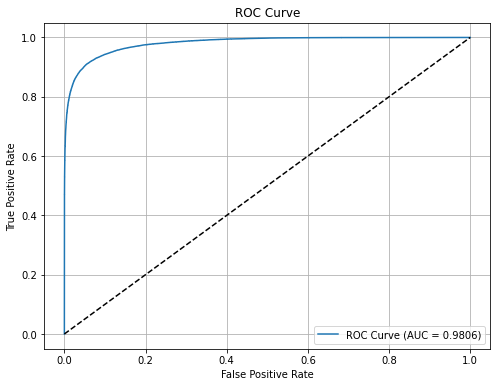

In [18]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob, sample_weight=weights_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

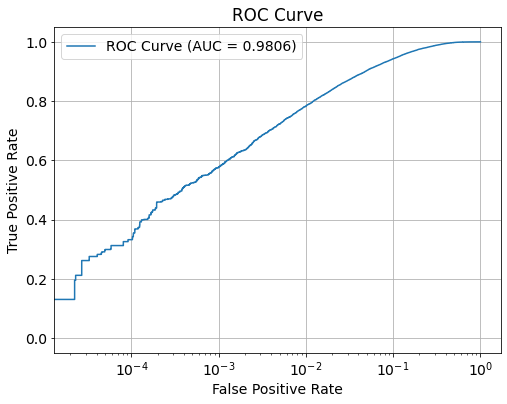

In [77]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob, sample_weight=weights_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

In [78]:
pipeline.feature_importances

AttributeError: 'Pipeline' object has no attribute 'feature_importances'

## 3. Let's plot some outcomes

In [51]:
results = X_test.copy()
results['set'] = yset_test
results['y'] = np.array(y_test)
results['ypred'] = y_pred
results['yprob'] = y_pred_prob
results['weight'] = weights_test

get_rates(results, header = r"After BDT", factor=1/test_size)

After BDT:
   CC_numu: 5435.4400088344655 (N_MC = 20941)
   CC_nuebar: 113.5040715134876 (N_MC = 784)
   NC_numu: 4989.017489777738 (N_MC = 39348)
   NC_nuebar: 2198.480660581417 (N_MC = 41821)
   0.125GeV: 5252.68752026274 (N_MC = 70167)
   20GeV: 0.0 (N_MC = 0)


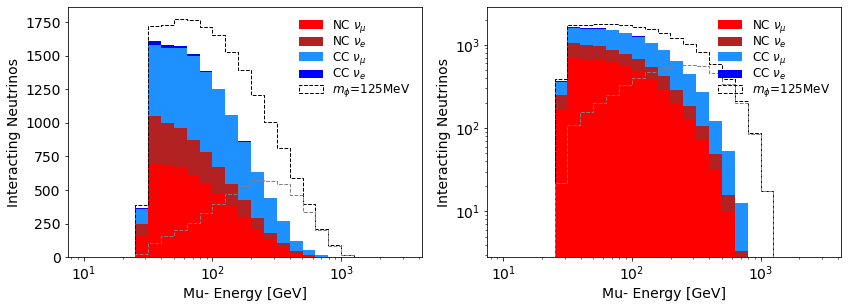

In [52]:
get_stacked_histogram(
    data=results, 
    observable="e_mu_plus", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="Mu- Energy [GeV]", 
    xlog=True,
    coupling=1,
    factor=1./test_size,
)

In [53]:
passed = results[results['ypred']==1]
get_rates(passed, header = r"After BDT", factor=1/test_size)

After BDT:
   CC_numu: 0.0 (N_MC = 0)
   CC_nuebar: 2.4199191455241182 (N_MC = 28)
   NC_numu: 213.91720470105645 (N_MC = 2217)
   NC_nuebar: 153.73102637639658 (N_MC = 3187)
   0.125GeV: 4553.6311358521725 (N_MC = 63106)
   20GeV: 0.0 (N_MC = 0)


In [58]:
passed = results[results['yprob']>0.9]
get_rates(passed, header = r"After BDT", factor=1/test_size)

After BDT:
   CC_numu: 0.0 (N_MC = 0)
   CC_nuebar: 0.0 (N_MC = 0)
   NC_numu: 11.760916053208364 (N_MC = 137)
   NC_nuebar: 8.418909340297798 (N_MC = 213)
   0.125GeV: 3266.00895103443 (N_MC = 44984)
   20GeV: 0.0 (N_MC = 0)


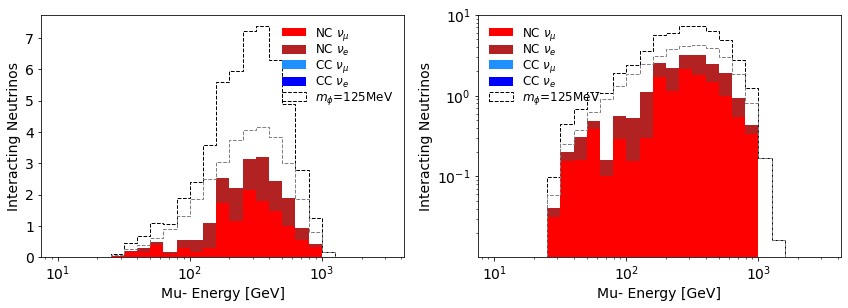

In [59]:
get_stacked_histogram(
    data=passed, 
    observable="e_mu_plus", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="Mu- Energy [GeV]", 
    xlog=True,
    coupling=.1,
    factor=1./test_size,
)

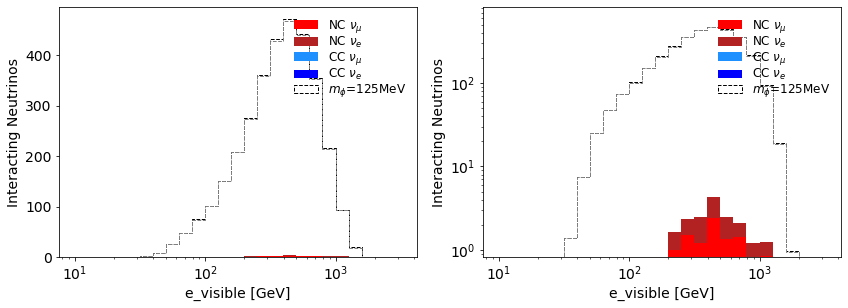

In [60]:
get_stacked_histogram(
    data=passed, 
    observable="e_visible", 
    bins=np.logspace(1,3.5,25+1), 
    xlabel="e_visible [GeV]", 
    xlog=True,
    coupling=1,
    factor=1./test_size,
)

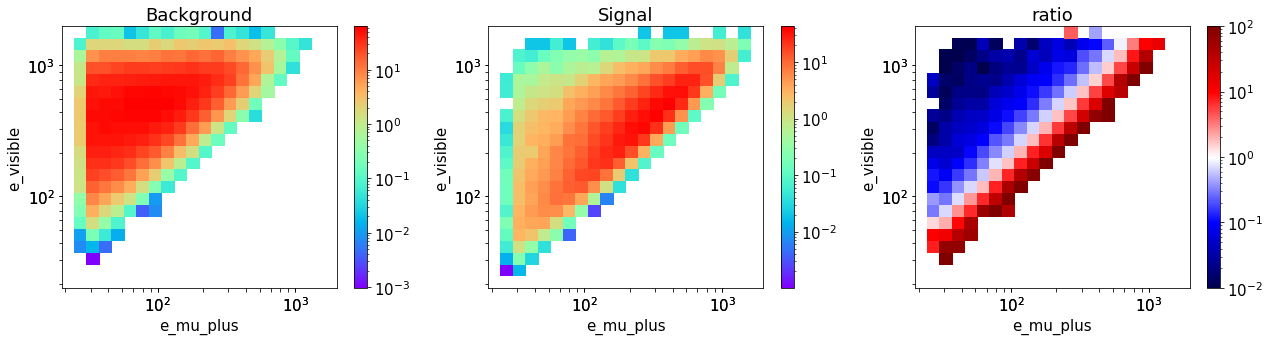

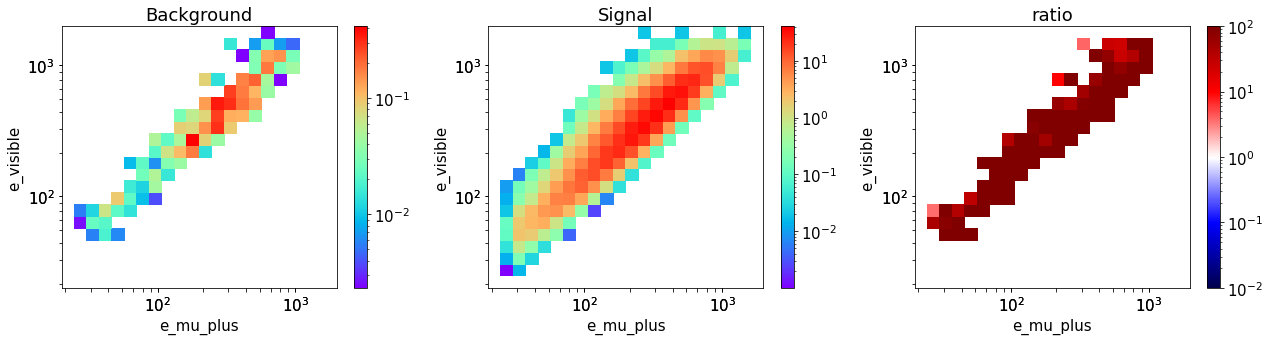

In [67]:
varx='e_mu_plus'
vary='e_visible'
    
plot_2d(
    data0=results[results['y']==0], 
    data1=results[results['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [1.3,3.3,21],
)

plot_2d(
    data0=passed[passed['y']==0], 
    data1=passed[passed['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [1.3,3.3,21],
)

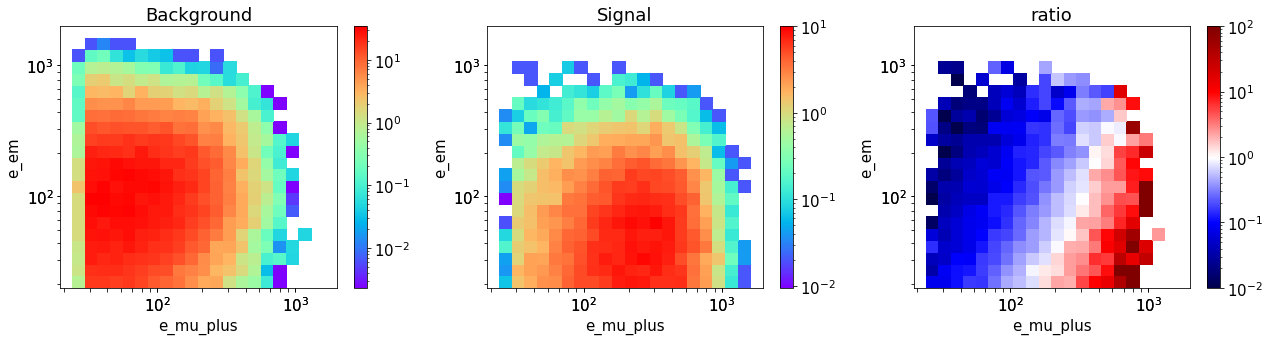

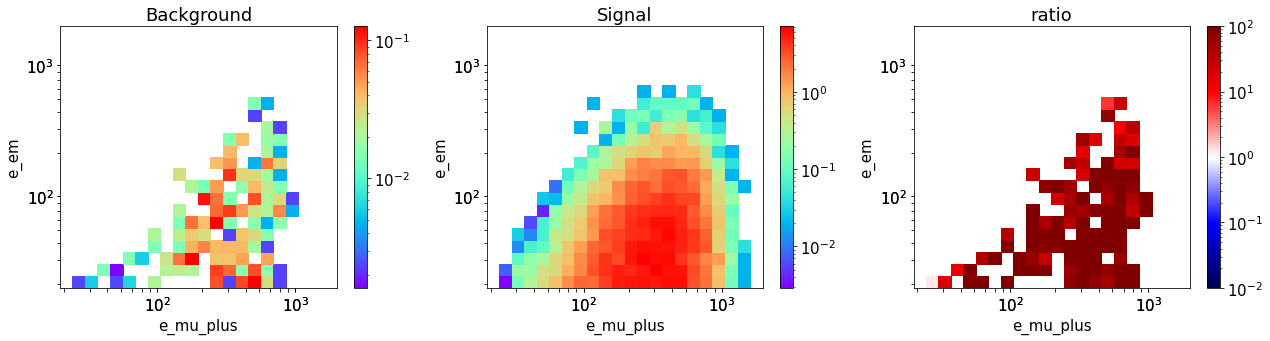

In [73]:
varx='e_mu_plus'
vary='e_em'
    
plot_2d(
    data0=results[results['y']==0], 
    data1=results[results['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [1.3,3.3,21],
)

plot_2d(
    data0=passed[passed['y']==0], 
    data1=passed[passed['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [1.3,3.3,21],
)

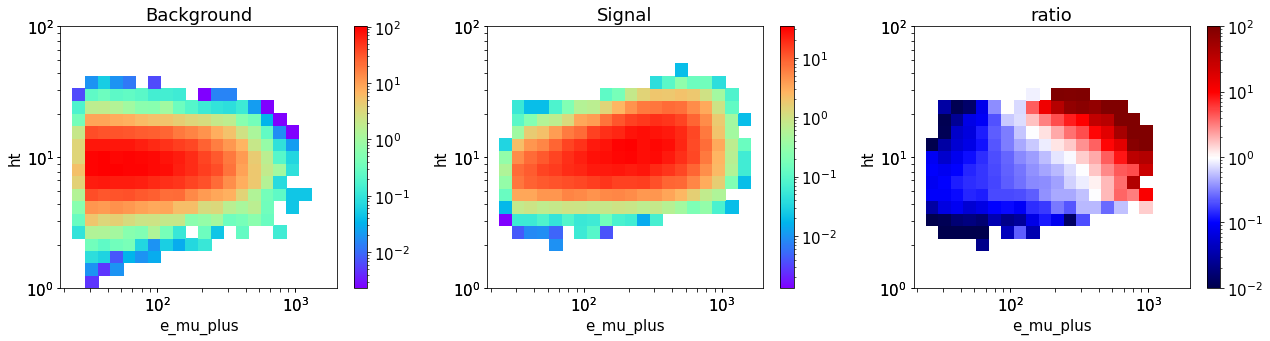

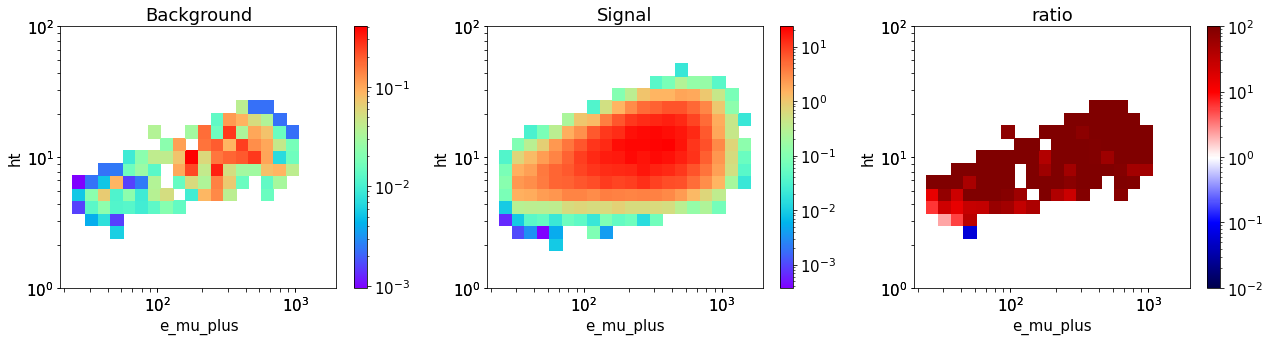

In [74]:
varx='e_mu_plus'
vary='ht'
    
plot_2d(
    data0=results[results['y']==0], 
    data1=results[results['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [0,2,20],
)

plot_2d(
    data0=passed[passed['y']==0], 
    data1=passed[passed['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [0,2,20],
)

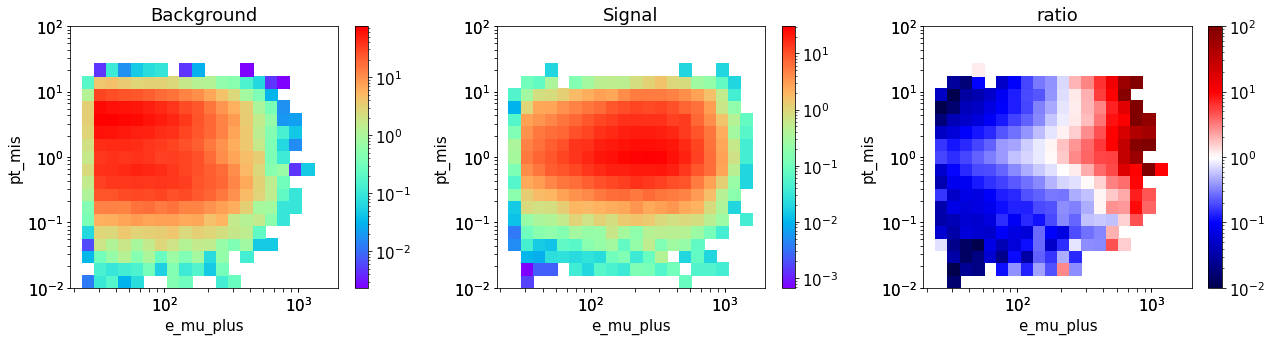

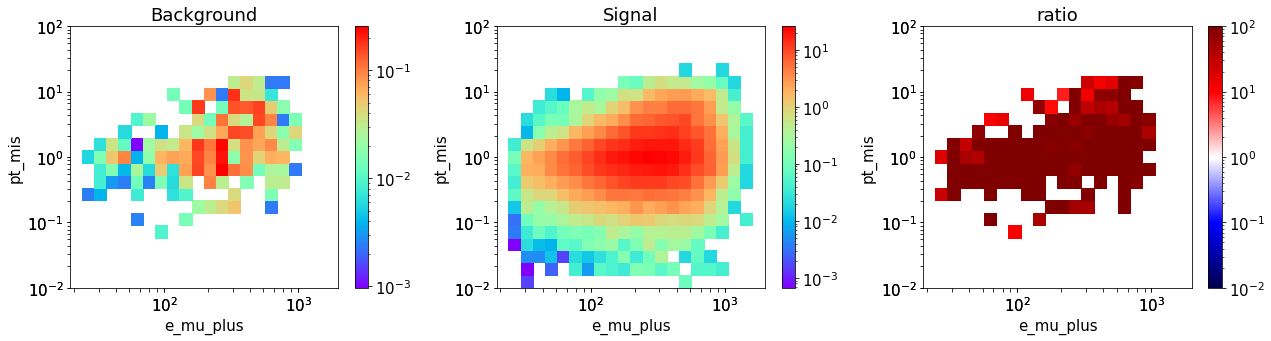

In [70]:
varx='e_mu_plus'
vary='pt_mis'
    
plot_2d(
    data0=results[results['y']==0], 
    data1=results[results['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [-2,2,20],
)

plot_2d(
    data0=passed[passed['y']==0], 
    data1=passed[passed['y']==1], 
    varx=varx, 
    vary=vary, 
    binsx = [1.3,3.3,21],
    binsy = [-2,2,20],
)

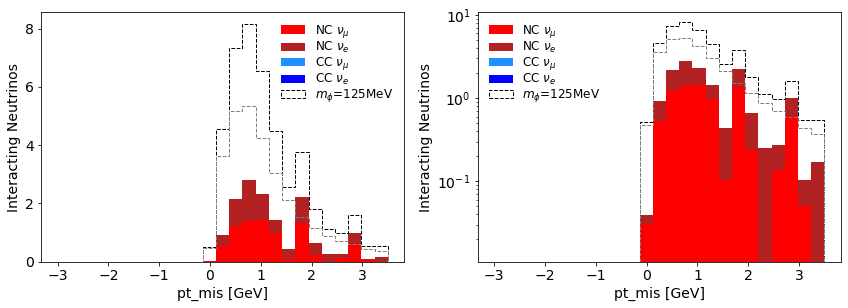

In [75]:
get_stacked_histogram(
    data=passed, 
    observable="pt_mis", 
    bins=np.linspace(-3,3.5,25+1), 
    xlabel="pt_mis [GeV]", 
    xlog=False,
    coupling=0.1,
    factor=1./test_size,
)